In [12]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd 

In [13]:
r = lambda x, y: np.sqrt(x**2 + y**2)

# indice de refraccion de aproximacion eikonal
n = lambda x, y, rmax: 1/ (1 - rmax/ r(x, y))

# Falctor de correccion
corr = lambda x, y, rmax: np.abs(1 - 9/8 * (rmax/ r(x, y))**2)


Las ecuaciones que describen la trayectoria $(x, y)$ y la velocidad $(v_x, v_y)$ de un rayo en esta aproximación viene dada por: 

$$
\frac{dx}{dt} = \frac{v_x}{n(x, y)} \quad \wedge \quad \frac{dy}{dt} = \frac{v_y}{n(x,y)}
$$

y:

$$
\frac{d\, v_x}{dt} = \frac{\partial }{\partial x} n(x, y) \quad \wedge \quad \frac{d\,v_y}{dt} = \frac{\partial}{\partial y} n(x, y)
$$

In [22]:
# definimos las ecuaciones diferenciales de la trayectoria de la luz

def refindex(x, y, A=1.0):
    eps = 1e-6       # correccion para evitar singularidades numéricas
    rp0 = np.sqrt(x**2 + y**2)
    n = 1 / (1 - A / (rp0 + eps))
    fac = np.abs(1 - 9 * (A / rp0)**2 / 8)
    nx = -fac * n**2 * A * x / (rp0 + eps)**3
    ny = -fac * n**2 * A * y / (rp0 + eps)**3
    return n, nx, ny

def flow_deriv(t, state):
    x, y, vx, vy = state
    n_value, nx, ny = refindex(x, y)
    return np.array([vx / n_value, vy / n_value, nx, ny])


## **integración de rayos en el plano $x-y$**

In [16]:
N = 1000 # numero de posiciones iniciales a generar
R = 70 # radio sugerido

# Generamos posiciones iniciales aleatorias dentro de un círculo de radio R
theta = np.random.uniform(0, 2*np.pi, N)
rs = R * np.sqrt(np.random.uniform(0, 1, N))

# posiciones cartesianas en el plano y-z
y = rs * np.cos(theta)
z = rs * np.sin(theta)
x = np.zeros(N)  # eje x

# lo convertimos a coordenadas cilindricas
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arctan2(y, x)


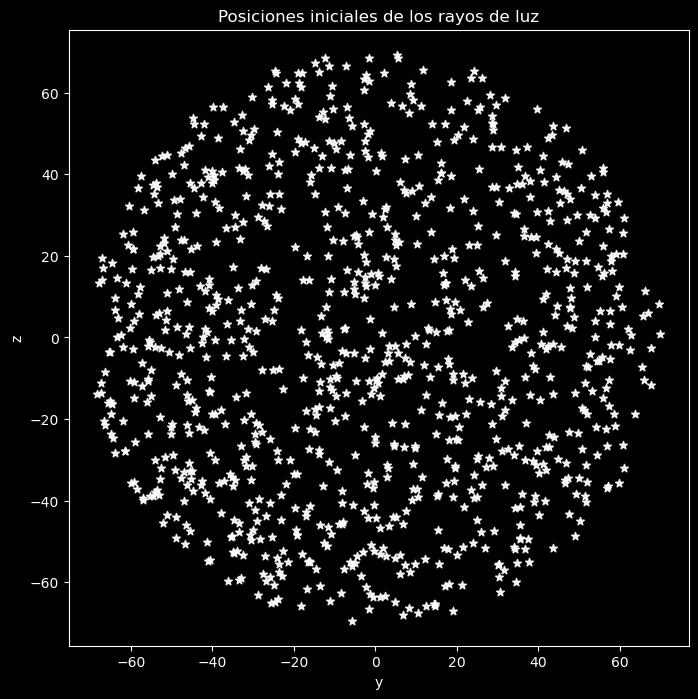

In [17]:
# visualizacion de los puntos en el plano

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(y, z, s=35, c='white', marker='*', alpha=0.9)
plt.title('Posiciones iniciales de los rayos de luz', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
plt.show()

## **Integración de rayos en plano $x-y$**

In [20]:
# inicializamos el proceso de integración para la aproximacion eikonal
x0, y0 = -100*np.ones(N), rs

tspan = [0, 400]

# array detiempo con paso 1
ts = np.arange(0, 400, 1)

[-100. -100. -100. -100. -100. -100. -100. -100. -100. -100.]


Resolvemos la ecuacion para todos los rayos


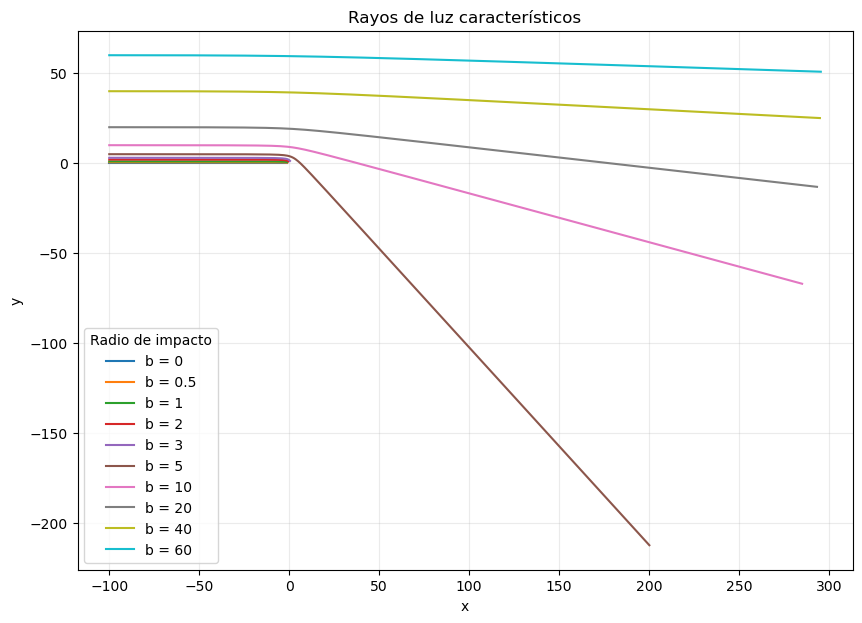

Rayos integrados: 10
Rayos capturados por r < 1.001: 5


In [27]:
# resolvemos el sistema de ecuaciones diferenciales para rayos característicos

# Radios de impacto seleccionados: desde un rayo casi central hasta uno lejano.
selected_radii = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 40.0, 60.0])
ray_solutions = []
captured_rays = []
horizon = 1.0 + 1e-3

def capture_event(t, state):
    x, y = state[:2]
    return np.sqrt(x**2 + y**2) - horizon

capture_event.terminal = True
capture_event.direction = -1

for radius in selected_radii:
    initial_state = [-100.0, float(radius), 1.0, 0.0]
    solution = solve_ivp(
        flow_deriv,
        tspan,
        initial_state,
        t_eval=ts,
        events=capture_event,
        rtol=1e-7,
        atol=1e-9
    )
    if not solution.success and len(solution.t) == 0:
        raise RuntimeError(f'No se pudo integrar el rayo con y0={radius}: {solution.message}')

    trajectory = np.full((4, len(ts)), np.nan)
    trajectory[:, :solution.y.shape[1]] = solution.y
    ray_solutions.append(trajectory)
    captured_rays.append(len(solution.t_events[0]) > 0)

# Forma: (numero_de_rayos, 4, numero_de_tiempos)
ray_solutions = np.stack(ray_solutions)
captured_rays = np.array(captured_rays)
x_rays = ray_solutions[:, 0, :]
y_rays = ray_solutions[:, 1, :]
vx_rays = ray_solutions[:, 2, :]
vy_rays = ray_solutions[:, 3, :]

plt.figure(figsize=(10, 7))
for index, (ray_x, ray_y) in enumerate(zip(x_rays, y_rays)):
    plt.plot(ray_x, ray_y, label=f'b = {selected_radii[index]:g}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rayos de luz característicos')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.legend(title='Radio de impacto')
plt.show()

print(f'Rayos integrados: {len(ray_solutions)}')
print(f'Rayos capturados por r < {horizon}: {captured_rays.sum()}')
